# Retrieval evaluation — RAG layer

Measures whether the system finds the right footage for a natural-language
question, over the MEVA event annotations indexed in Qdrant.

**Scope: retrieval only.** Everything here is computed from the events returned
by the search, before any language model is called — so these numbers are
independent of which LLM is configured, and reproducible.

**Method.** Each question carries criteria describing what counts as a correct
answer (caption terms, plus optional location, camera, date and time
constraints). The answer key is built by scanning caption text directly. The
system under test never sees those criteria: it receives only the question.
Building the key from our own search results would grade the system against
itself.

**Two conditions**, same questions: metadata filtering on (how the system
actually behaves) and off (pure vector search), so the contribution of
filtering is measurable rather than assumed.

In [1]:
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent / "src"))

from rag import filters, store                      # noqa: E402
from rag.config import COLLECTION, EMBED_DIM, EMBED_MODEL  # noqa: E402
from rag.pipeline import MIN_SCORE, PROMPT_VERSION, TOP_K, retrieve  # noqa: E402

client = store.connect()
events = [p.payload for p in client.scroll(COLLECTION, limit=10000, with_payload=True)[0]]

run_info = pd.Series({
    "collection": COLLECTION,
    "events indexed": len(events),
    "videos": len({e["video_name"] for e in events}),
    "locations": len({e["scene"] for e in events}),
    "cameras": len({e["camera_id"] for e in events}),
    "embedding model": EMBED_MODEL,
    "embedding dims": EMBED_DIM,
    "TOP_K": TOP_K,
    "MIN_SCORE": MIN_SCORE,
    "prompt version": PROMPT_VERSION,
}, name="value")
run_info.to_frame()

,value
collection,meva_events
events indexed,2013
videos,71
locations,4
cameras,23
embedding model,BAAI/bge-base-en-v1.5
embedding dims,768
TOP_K,5
MIN_SCORE,0.6
prompt version,2026-09-24.v5


## The question set

30 questions across eight categories. Difficulty is deliberately uneven: some
have a handful of relevant events in the whole corpus, others thousands.

- **lookup** — plain semantic search, no filter expected
- **location / camera / date / time / combined** — one or more metadata filters
- **negative** — nothing should match; verified absent from every caption
- **refusal** — the filter extractor should decline to guess, and say why

In [2]:
questions = pd.read_csv("questions.csv").fillna("")
questions["expect_nothing"] = questions["expect_nothing"].astype(str).str.upper() == "TRUE"
questions[["id", "category", "question", "expect_nothing"]]

,id,category,question,expect_nothing
0,q01,lookup,Did anyone get out of a vehicle?,False
1,q02,lookup,Is anyone carrying a backpack?,False
2,q03,lookup,Did anyone use a phone?,False
3,q04,lookup,Was there a white SUV?,False
4,q05,lookup,Is there a bicycle anywhere in the footage?,False
5,q06,lookup,Were there groups of people?,False
6,q07,lookup,Did anyone walk up or down stairs?,False
7,q08,location,What happened at the hospital?,False
8,q09,location,Was there a motorcycle at the hospital?,False
9,q10,location,Did anyone take the stairs in the admin building?,False


## Building the answer key

For each question, every indexed event is checked against the criteria. An
event is relevant if its caption matches `match_any` **and** it satisfies any
location, camera, date or time constraint. The relevant events' videos become
the expected set.

This is lexical, and the search being tested is semantic — so the system has to
bridge a vocabulary gap the answer key does not. That makes these scores a
**lower bound**: a correct result phrased differently from the key counts as a
miss. Erring pessimistic is the safer direction.

In [3]:
def to_seconds(hhmm):
    h, m = hhmm.split(":")
    return int(h) * 3600 + int(m) * 60


def relevant_events(row):
    pattern = re.compile(row.match_any) if row.match_any else None
    out = []
    for e in events:
        if pattern and not pattern.search((e.get("description") or "").lower()):
            continue
        if row.scene and e.get("scene") != row.scene:
            continue
        if row.camera and e.get("camera_id") != row.camera:
            continue
        if row.date and e.get("capture_date") != row.date:
            continue
        tod = e.get("start_time_of_day")
        if row.time_from and (tod is None or tod < to_seconds(row.time_from)):
            continue
        if row.time_to and (tod is None or tod > to_seconds(row.time_to)):
            continue
        out.append(e)
    return out


answer_key = {}
for row in questions.itertuples():
    hits = relevant_events(row)
    answer_key[row.id] = {h["video_name"] for h in hits}

key_sizes = pd.DataFrame([
    {"id": r.id, "category": r.category, "question": r.question,
     "relevant videos": len(answer_key[r.id])}
    for r in questions.itertuples()
])
key_sizes

,id,category,question,relevant videos
0,q01,lookup,Did anyone get out of a vehicle?,5
1,q02,lookup,Is anyone carrying a backpack?,34
2,q03,lookup,Did anyone use a phone?,24
3,q04,lookup,Was there a white SUV?,30
4,q05,lookup,Is there a bicycle anywhere in the footage?,5
5,q06,lookup,Were there groups of people?,22
6,q07,lookup,Did anyone walk up or down stairs?,24
7,q08,location,What happened at the hospital?,7
8,q09,location,Was there a motorcycle at the hospital?,1
9,q10,location,Did anyone take the stairs in the admin building?,6


## Running the questions

Each question is run twice — filters on, then off — and the top `TOP_K` results
recorded. A question scores a hit at rank *k* if any video in the answer key
appears in the first *k* results.

In [4]:
records = []
for row in questions.itertuples():
    for use_filters in (True, False):
        sources, spec = retrieve(row.question, use_filters=use_filters)
        videos = [s["video_name"] for s in sources]
        key = answer_key[row.id]
        first_hit = next((i for i, v in enumerate(videos, 1) if v in key), None)
        records.append({
            "id": row.id,
            "category": row.category,
            "question": row.question,
            "condition": "filters on" if use_filters else "filters off",
            "returned": len(sources),
            "first_hit_rank": first_hit,
            "top_score": sources[0]["score"] if sources else None,
            "filter": spec.describe(),
            "expect_nothing": row.expect_nothing,
            "expect_note": row.expect_note,
            "scores": [s["score"] for s in sources],
            "videos": videos,
        })

results = pd.DataFrame(records)
print(f"{len(results)} runs: {len(questions)} questions x 2 conditions")
results[["id", "condition", "returned", "first_hit_rank", "filter"]].head(10)

60 runs: 30 questions x 2 conditions


,id,condition,returned,first_hit_rank,filter
0,q01,filters on,5,1.0,none
1,q01,filters off,5,1.0,none
2,q02,filters on,5,1.0,none
3,q02,filters off,5,1.0,none
4,q03,filters on,0,NaN,none
5,q03,filters off,0,NaN,none
6,q04,filters on,5,1.0,none
7,q04,filters off,5,1.0,none
8,q05,filters on,5,1.0,none
9,q05,filters off,5,1.0,none


## Headline metrics

Computed over the **answerable** questions only — the negative and refusal
categories have no correct footage by design, so including them would distort
the averages. They are scored separately below.

- **Hit@k** — the correct video appeared within the first *k* results
- **MRR** — mean reciprocal rank; rank 1 scores 1.0, rank 2 scores 0.5, rank 3
  scores 0.33. It separates "found at the top" from "found at the bottom",
  which Hit@5 alone hides.

Counts, not percentages: with this many questions a single question moves a
percentage several points, which would imply precision we do not have.

In [5]:
ANSWERABLE = ["lookup", "location", "camera", "date", "time", "combined"]
answerable = results[results.category.isin(ANSWERABLE)]
n_answerable = answerable.id.nunique()

rows = []
for condition, group in answerable.groupby("condition", sort=False):
    rank = group.first_hit_rank
    rows.append({
        "condition": condition,
        "Hit@1": int((rank == 1).sum()),
        "Hit@3": int((rank <= 3).sum()),
        "Hit@5": int((rank <= 5).sum()),
        "out of": n_answerable,
        "MRR": round(float((1 / rank.dropna()).sum() / len(group)), 3),
        "returned nothing": int((group.returned == 0).sum()),
    })
headline = pd.DataFrame(rows).set_index("condition")
headline

,Hit@1,Hit@3,Hit@5,out of,MRR,returned nothing
condition,,,,,,
filters on,20,20,20,22,0.909,2
filters off,9,9,9,22,0.409,12


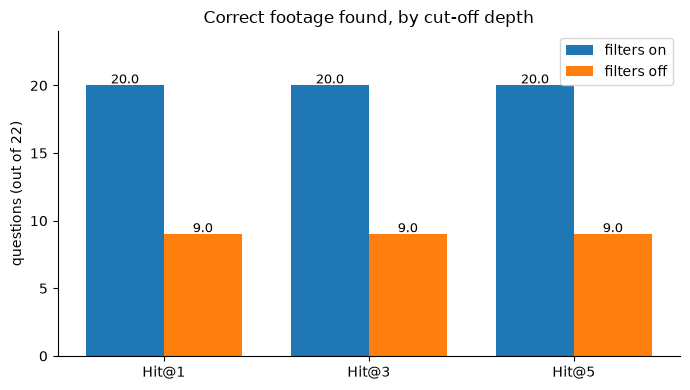

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
metrics = ["Hit@1", "Hit@3", "Hit@5"]
x = range(len(metrics))
width = 0.38
for i, (condition, row) in enumerate(headline.iterrows()):
    ax.bar([p + i * width for p in x], [row[m] for m in metrics],
           width, label=condition)
    for p, m in zip(x, metrics):
        ax.text(p + i * width, row[m] + 0.15, str(row[m]), ha="center", fontsize=9)
ax.set_xticks([p + width / 2 for p in x])
ax.set_xticklabels(metrics)
ax.set_ylabel(f"questions (out of {n_answerable})")
ax.set_ylim(0, n_answerable + 2)
ax.set_title("Correct footage found, by cut-off depth")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Where the correct result landed

Hit@5 treats rank 1 and rank 5 identically, but they are very different for a
user scanning results. This shows, per question, how far down the first correct
video appeared. Questions with no bar returned no correct video at all.

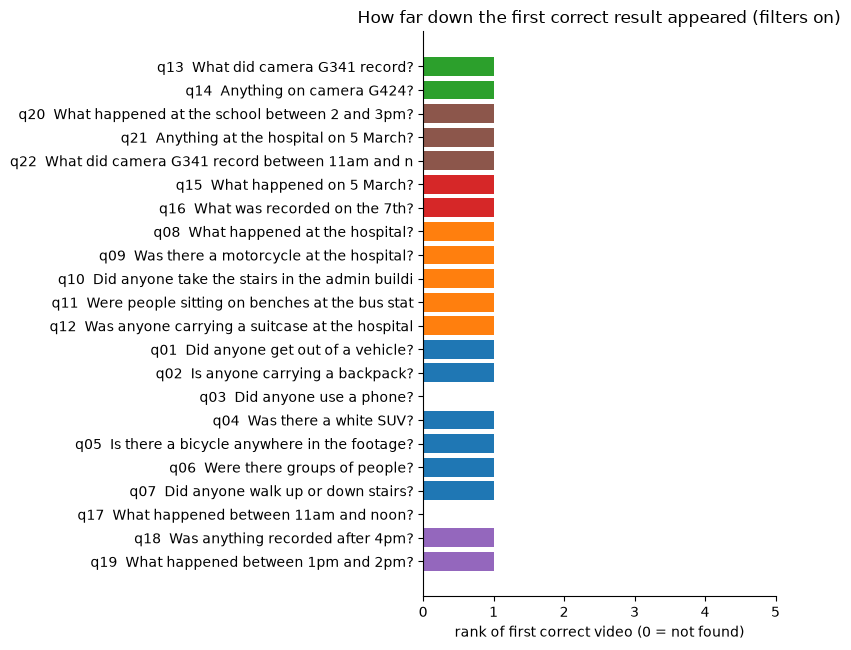

In [7]:
on = (answerable[answerable.condition == "filters on"]
      .sort_values(["category", "id"]))

fig, ax = plt.subplots(figsize=(8, max(4, len(on) * 0.3)))
labels, values, colours = [], [], []
palette = {c: f"C{i}" for i, c in enumerate(ANSWERABLE)}
for r in on.itertuples():
    labels.append(f"{r.id}  {r.question[:46]}")
    values.append(r.first_hit_rank if r.first_hit_rank else 0)
    colours.append(palette[r.category])
ax.barh(labels, values, color=colours)
ax.invert_yaxis()
ax.set_xlabel("rank of first correct video (0 = not found)")
ax.set_xticks(range(0, TOP_K + 1))
ax.set_title("How far down the first correct result appeared (filters on)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Negative questions

Five questions ask about things verified absent from every caption — an
ambulance, a helicopter, a dog, an umbrella, children. A system that always
returns something scores well on recall-style measures while being useless in
practice, so this is measured explicitly.

**Correct = returned nothing.**

In [8]:
negatives = results[(results.category == "negative") & (results.condition == "filters on")]
neg_table = negatives[["id", "question", "returned", "top_score"]].copy()
neg_table["correct"] = neg_table.returned == 0
neg_table = neg_table.set_index("id")
print(f"correctly refused: {int(neg_table.correct.sum())} of {len(neg_table)}")
neg_table

correctly refused: 4 of 5


,question,returned,top_score,correct
id,,,,
q23,Did an ambulance arrive at the hospital?,5,0.592,False
q24,Is there a helicopter anywhere in the footage?,0,NaN,True
q25,Did anyone bring a dog?,0,NaN,True
q26,Was anyone using an umbrella?,0,NaN,True
q27,Are there any children in the footage?,0,NaN,True


## Filter behaviour

What the rule-based extractor pulled out of each question, and where it
deliberately refused rather than guessed. The refusal cases are scored on
whether the refusal was recorded, not on retrieval.

In [9]:
filt = results[results.condition == "filters on"][["id", "category", "question", "filter"]]
filt = filt[filt.category.isin(["location", "camera", "date", "time", "combined", "refusal"])]
filt.set_index("id")

,category,question,filter
id,,,
q08,location,What happened at the hospital?,location hospital
q09,location,Was there a motorcycle at the hospital?,location hospital
q10,location,Did anyone take the stairs in the admin building?,location admin
q11,location,Were people sitting on benches at the bus stat...,location bus
q12,location,Was anyone carrying a suitcase at the hospital?,location hospital
q13,camera,What did camera G341 record?,camera G341
q14,camera,Anything on camera G424?,camera G424
q15,date,What happened on 5 March?,date 2018-03-05
q16,date,What was recorded on the 7th?,date 2018-03-07


In [10]:
refusals = results[(results.category == "refusal") & (results.condition == "filters on")]
checks = []
for r in refusals.itertuples():
    checks.append({
        "id": r.id,
        "question": r.question,
        "expected to note": r.expect_note,
        "actual": r.filter,
        "correct": r.expect_note.lower() in r.filter.lower(),
    })
refusal_table = pd.DataFrame(checks).set_index("id")
print(f"refusals recorded correctly: {int(refusal_table.correct.sum())} of {len(refusal_table)}")
refusal_table

refusals recorded correctly: 3 of 3


,question,expected to note,actual,correct
id,,,,
q28,Was there a school bus?,ambiguous,"none, (ambiguous location (bus, school), not f...",True
q29,What happened at 2-4?,ignored time,"none, (ignored time: no am/pm given)",True
q30,Show me anything except at the school,excluded,"none, (ignored location school: looks excluded)",True


## Score distribution

Similarity scores for answerable questions against the negative questions,
which have no correct answer. The gap between them is what the `MIN_SCORE`
threshold relies on — and how cleanly they separate determines whether a fixed
threshold is a sound way to decide "nothing matches".

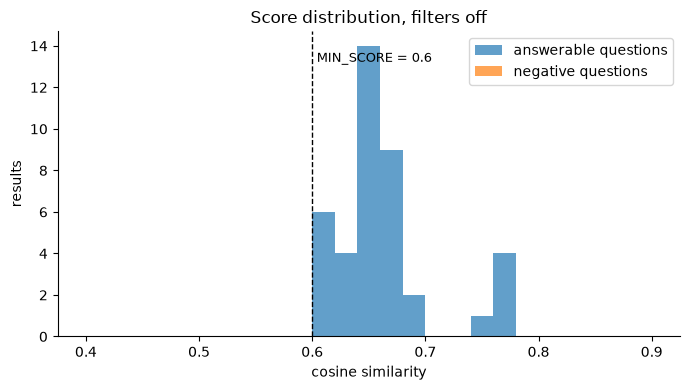

In [11]:
answer_scores = [s for r in answerable[answerable.condition == "filters off"].itertuples()
                 for s in r.scores]
neg_runs = results[(results.category == "negative") & (results.condition == "filters off")]
neg_scores = [s for r in neg_runs.itertuples() for s in r.scores]

fig, ax = plt.subplots(figsize=(7, 4))
bins = [i / 50 for i in range(20, 46)]
ax.hist(answer_scores, bins=bins, alpha=0.7, label="answerable questions")
ax.hist(neg_scores, bins=bins, alpha=0.7, label="negative questions")
ax.axvline(MIN_SCORE, linestyle="--", color="black", linewidth=1)
ax.text(MIN_SCORE + 0.004, ax.get_ylim()[1] * 0.9, f"MIN_SCORE = {MIN_SCORE}", fontsize=9)
ax.set_xlabel("cosine similarity")
ax.set_ylabel("results")
ax.set_title("Score distribution, filters off")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Limitations

**Sample size.** 30 questions. A difference of one or two between conditions is
not meaningful; only large gaps should be read as real.

**The answer key is lexical.** It is built by matching caption text, so a
correct result whose caption words differ from the key counts as a miss. Scores
here understate true performance rather than overstate it.

**This measures retrieval over captions, not over video.** If a caption
describes the footage wrongly, both the answer key and the search inherit that
error. Whether captions are faithful to the video is the annotation layer's
evaluation, deliberately separate from this one.

**Video-level credit.** A result counts as correct if it comes from a video
containing a relevant event, even if that particular event is not the relevant
one. Finer-grained scoring would need event-level ground truth.